In [2]:
import gridstatus
import pandas as pd
import ssl

# 1. Bypass SSL verification for your local VS Code environment
ssl._create_default_https_context = ssl._create_unverified_context

caiso = gridstatus.CAISO()
all_data = []

# 2. Fetch data year by year to avoid API timeouts
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    start_date = f"{year}-01-01"
    end_date = f"{year}-12-31"
    
    print(f"Fetching CAISO load data for {year}...")
    
    # Fetch the historical load data for the specific year
    yearly_data = caiso.get_load(date=start_date, end=end_date)
    all_data.append(yearly_data)
    
    print(f"Successfully fetched {len(yearly_data)} rows for {year}.")

# 3. Combine all the yearly dataframes into one
print("\nCombining all years into a single dataset...")
full_caiso_data = pd.concat(all_data, ignore_index=True)

# 4. Save the full 5-year dataset to CSV
filename = "caiso_load_2020_2024.csv"
full_caiso_data.to_csv(filename, index=False)

print(f"\nDone! Saved {len(full_caiso_data)} total rows to {filename}.")

Fetching CAISO load data for 2020...


 19%|█▊        | 68/365 [01:24<06:20,  1.28s/it]2026-09-24 22:39:32 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20200309/demand.csv?_=1790269772


Error: 2020-03-08 02:00:00
Args: {'self': <gridstatus.caiso.caiso.CAISO object at 0x0000024DC3625E50>, 'date': Timestamp('2020-03-08 00:00:00-0800', tz='US/Pacific')}



100%|██████████| 365/365 [07:33<00:00,  1.24s/it]


Errors that occurred while getting data:
[{'date': Timestamp('2020-03-08 00:00:00-0800', tz='US/Pacific'),
  'self': <gridstatus.caiso.caiso.CAISO object at 0x0000024DC3625E50>}]
Successfully fetched 104821 rows for 2020.
Fetching CAISO load data for 2021...


...

Successfully fetched 104804 rows for 2022.
Fetching CAISO load data for 2023...


100%|██████████| 364/364 [07:11<00:00,  1.18s/it]


Successfully fetched 104820 rows for 2023.
Fetching CAISO load data for 2024...


100%|██████████| 365/365 [07:16<00:00,  1.20s/it]


Successfully fetched 104894 rows for 2024.

Combining all years into a single dataset...

Done! Saved 524159 total rows to caiso_load_2020_2024.csv.


In [3]:
import pandas as pd
import requests

# --- Phase 1.2: Data Cleaning & Preprocessing ---
print("Loading local CAISO data...")
caiso_load_data = pd.read_csv("caiso_load_2020_2024.csv")

# Convert to UTC datetime to ensure safe timezone merging
caiso_load_data['Interval Start'] = pd.to_datetime(caiso_load_data['Interval Start'], utc=True)
caiso_load_data.set_index('Interval Start', inplace=True)

print("Resampling to hourly intervals...")
# Resample the 5-minute data to 1-hour intervals and handle missing values
hourly_load = caiso_load_data.resample('1h').mean(numeric_only=True)
hourly_load['Load'] = hourly_load['Load'].interpolate(method='time')


# --- Phase 1.3: External Data Integration (Open-Meteo) ---
print("Fetching 5 years of Open-Meteo weather data...")
weather_url = "https://archive-api.open-meteo.com/v1/archive"
weather_params = {
    "latitude": 34.0522,
    "longitude": -118.2437,
    "start_date": "2020-01-01",
    "end_date": "2024-12-31",
    "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"],
    "timezone": "America/Los_Angeles"
}

response = requests.get(weather_url, params=weather_params)
weather_data = response.json()

# Convert to DataFrame and align timestamps to UTC
weather_df = pd.DataFrame(weather_data['hourly'])
weather_df['time'] = pd.to_datetime(weather_df['time'], utc=True)
weather_df.set_index('time', inplace=True)

# Data Merging: Timestamp-based inner join
print("Merging load and weather data...")
final_dataset = hourly_load.join(weather_df, how='inner')

print("\nMerged Dataset (Load + Weather):")
print(final_dataset.head())
print(f"\nTotal hourly records: {len(final_dataset)}")

# Save the merged baseline dataset
final_dataset.to_csv("caiso_weather_merged_2020_2024.csv")
print("Saved to caiso_weather_merged_2020_2024.csv")

Loading local CAISO data...
Resampling to hourly intervals...
Fetching 5 years of Open-Meteo weather data...
Merging load and weather data...

Merged Dataset (Load + Weather):
                                   Load  temperature_2m  relative_humidity_2m  \
2020-01-01 08:00:00+00:00  21092.083333             7.1                    66   
2020-01-01 09:00:00+00:00  20312.333333             9.7                    62   
2020-01-01 10:00:00+00:00  19704.666667            12.7                    57   
2020-01-01 11:00:00+00:00  19348.750000            15.2                    49   
2020-01-01 12:00:00+00:00  19184.000000            16.5                    45   

                           wind_speed_10m  
2020-01-01 08:00:00+00:00             8.5  
2020-01-01 09:00:00+00:00             9.8  
2020-01-01 10:00:00+00:00             4.4  
2020-01-01 11:00:00+00:00             1.1  
2020-01-01 12:00:00+00:00             5.6  

Total hourly records: 43824
Saved to caiso_weather_merged_2020_2024.csv


In [4]:
import holidays

print("Loading merged 5-year dataset...")
# Load the dataset, parse dates, and set the first column as the index
df = pd.read_csv("caiso_weather_merged_2020_2024.csv", index_col=0, parse_dates=True)

print("Engineering temporal, calendar, and lag features...")

# --- 1. Temporal Features ---
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
# Flag weekends (5 = Saturday, 6 = Sunday)
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# --- 2. Calendar Flags ---
# Generate US holidays for California from 2020 through 2024
california_holidays = holidays.US(subdiv='CA', years=[2020, 2021, 2022, 2023, 2024])
df['is_holiday'] = df.index.map(lambda d: d in california_holidays).astype(int)

# --- 3. Lag & Rolling Metrics ---
# 24-hour lag and rolling mean
df['load_lag_24h'] = df['Load'].shift(24)
df['rolling_mean_24h'] = df['Load'].rolling(window=24).mean()

# 7-day (168 hours) rolling maximum
df['rolling_max_7d'] = df['Load'].rolling(window=168).max()

# Drop the NaN rows created at the start of the dataset by the 168-hour rolling window
df_engineered = df.dropna()

print(f"\nFinal engineered dataset contains {len(df_engineered)} records.")
print(df_engineered[['Load', 'hour', 'is_holiday', 'load_lag_24h', 'rolling_max_7d']].head())

# Save the final preprocessed dataset
df_engineered.to_csv("caiso_engineered_features_2020_2024.csv")
print("\nSaved to caiso_engineered_features_2020_2024.csv!")

Loading merged 5-year dataset...
Engineering temporal, calendar, and lag features...

Final engineered dataset contains 43657 records.
                                   Load  hour  is_holiday  load_lag_24h  \
2020-01-08 07:00:00+00:00  21887.083333     7           0  21781.916667   
2020-01-08 08:00:00+00:00  20721.083333     8           0  20686.166667   
2020-01-08 09:00:00+00:00  19941.833333     9           0  19963.083333   
2020-01-08 10:00:00+00:00  19512.250000    10           0  19534.250000   
2020-01-08 11:00:00+00:00  19424.250000    11           0  19472.333333   

                           rolling_max_7d  
2020-01-08 07:00:00+00:00    27936.333333  
2020-01-08 08:00:00+00:00    27936.333333  
2020-01-08 09:00:00+00:00    27936.333333  
2020-01-08 10:00:00+00:00    27936.333333  
2020-01-08 11:00:00+00:00    27936.333333  

Saved to caiso_engineered_features_2020_2024.csv!


Loading 5-year engineered dataset...
Training records: 34889 | Testing records: 8768

Training XGBoost baseline model on 4 years of data...

--- 5-Year Baseline Performance ---
MAE:  787.15 MW
RMSE: 1155.26 MW


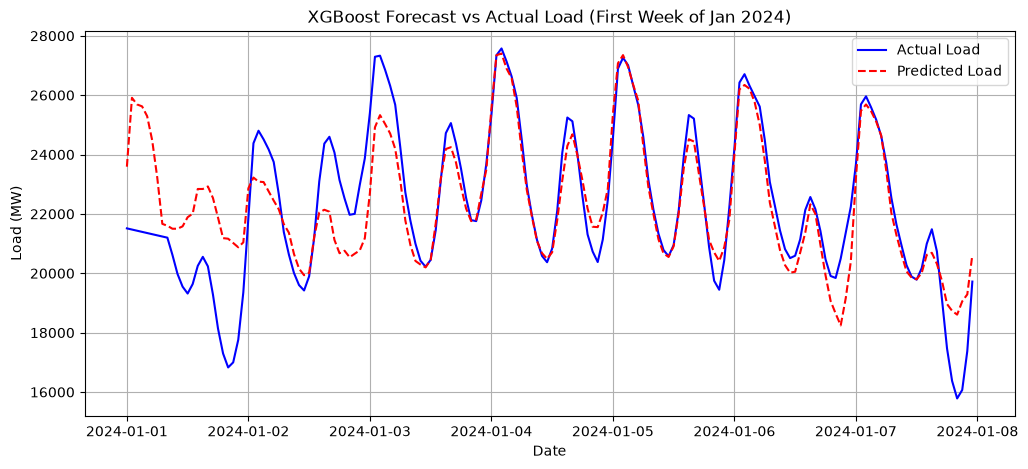

In [5]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("Loading 5-year engineered dataset...")
# Load the dataset, using the first column as the datetime index
df = pd.read_csv("caiso_engineered_features_2020_2024.csv", index_col=0, parse_dates=True)

# 1. Define Features and Target
features = [
    'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 
    'load_lag_24h', 'rolling_mean_24h', 'rolling_max_7d'
]
target = 'Load'

X = df[features]
y = df[target]

# 2. Chronological Train-Test Split 
# Train on 2020-2023, Test on 2024
split_date = '2024-01-01'
X_train = X.loc[X.index < split_date]
X_test = X.loc[X.index >= split_date]
y_train = y.loc[y.index < split_date]
y_test = y.loc[y.index >= split_date]

print(f"Training records: {len(X_train)} | Testing records: {len(X_test)}")

# 3. Initialize and Train XGBoost
print("\nTraining XGBoost baseline model on 4 years of data...")
xgb_model = xgb.XGBRegressor(
    n_estimators=150, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 4. Predict and Evaluate
predictions = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"\n--- 5-Year Baseline Performance ---")
print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")

# 5. Visual Check: Plot the first week of predictions vs actuals in 2024
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual Load', color='blue')
plt.plot(y_test.index[:168], predictions[:168], label='Predicted Load', color='red', linestyle='dashed')
plt.title('XGBoost Forecast vs Actual Load (First Week of Jan 2024)')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.legend()
plt.grid(True)
plt.show()